In [27]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [28]:
from utils.datasets.base_dataset import QUERY_TYPE
from pathlib import Path
import pandas as pd


In [41]:
results_dir = Path("scratch") / "results" 
def combine_dfs(pattern: str, base_dir: Path) -> pd.DataFrame:
    dfs = []
    for file in base_dir.glob(pattern):
        df = pd.read_csv(file)
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

stats_df = combine_dfs("bsbm_stats*.csv", results_dir)
# timings_df = combine_dfs("bsbm_timings*.csv", results_dir)
timings_df = pd.read_csv(Path("scratch") / "bdsdm_timings.csv")

In [42]:
timings_df

,size,power,estimated_size,elapsed_time,rep,engine,difficulty,query_type,ndcg_score
0,2418,3,1,0.962367,0,FusekiDB + RDFTensor,easy,embedded,1.0
1,2418,3,1,0.075958,1,FusekiDB + RDFTensor,easy,embedded,1.0
2,2418,3,1,0.072547,2,FusekiDB + RDFTensor,easy,embedded,1.0
3,2418,3,1,0.049229,3,FusekiDB + RDFTensor,easy,embedded,1.0
4,2418,3,1,0.041731,4,FusekiDB + RDFTensor,easy,embedded,1.0
...,...,...,...,...,...,...,...,...,...
235,3577077,6,10000,0.990322,11,Qlever (no Tensor Vocabulary),easy,embedded,1.0
236,3577077,6,10000,0.993436,12,Qlever (no Tensor Vocabulary),easy,embedded,1.0
237,3577077,6,10000,0.993202,13,Qlever (no Tensor Vocabulary),easy,embedded,1.0
238,3577077,6,10000,0.991418,14,Qlever (no Tensor Vocabulary),easy,embedded,1.0


In [43]:
# timings_df.to_csv("./scratch/bdsdm_timings.csv", index=False)
timings_df["engine"].unique()

<ArrowStringArray>
['FusekiDB + RDFTensor', 'Qlever', 'Qlever (no Tensor Vocabulary)']
Length: 3, dtype: str

In [44]:
engines = timings_df["engine"].unique()
difficulties = timings_df["difficulty"].unique()

In [45]:
groupings = timings_df.groupby(["estimated_size", "engine", "difficulty", "query_type"])[
    "elapsed_time"
]
quantiles = [0.05, 0.95]
median_timings = groupings.median().reset_index()
quantile_timings = groupings.quantile(quantiles).unstack().reset_index()

In [46]:
colors = {eng: color for eng, color in zip(engines, ["C0", "C1", "C2", "C3", "C4"])}
colors

{'FusekiDB + RDFTensor': 'C0',
 'Qlever': 'C1',
 'Qlever (no Tensor Vocabulary)': 'C2'}

/tmp/ipykernel_4154869/2830796753.py:28: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(


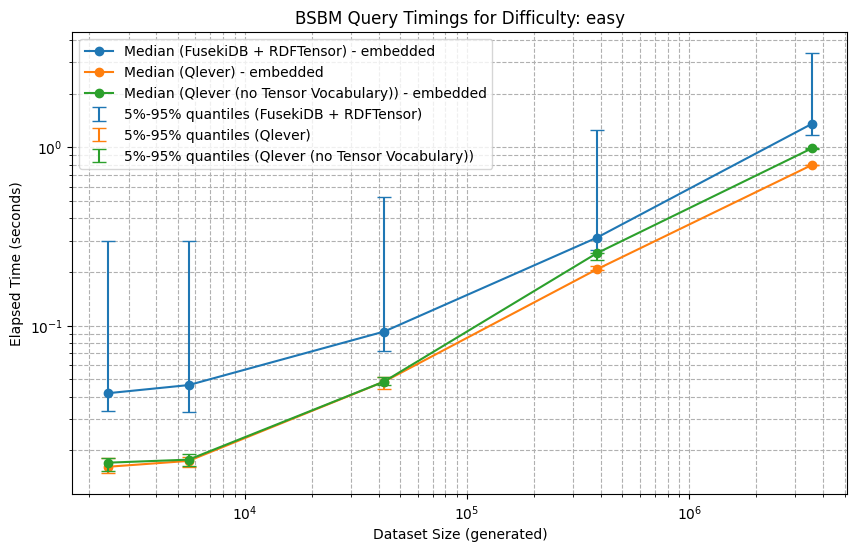

In [ ]:
import matplotlib.pyplot as plt

# plot the timings as double-log plot with error bars for the 5% and 95% quantiles
def plot_timings(ax, df, engine, difficulty, relevant_measure="elapsed_time"):
    groupings = df.groupby(["size", "engine", "difficulty", "query_type"])[
        relevant_measure
    ]
    quantiles = [0.05, 0.95]
    median_timings = groupings.median().reset_index()
    quantile_timings = groupings.quantile(quantiles).unstack().reset_index()
    for query_type in QUERY_TYPE:
        for engine in median_timings["engine"].unique():
            engine_median = median_timings[
                (median_timings["query_type"] == query_type.value)
                & (median_timings["difficulty"] == difficulty)
                & (median_timings["engine"] == engine)
            ]
            engine_quantiles = quantile_timings[
                (quantile_timings["query_type"] == query_type.value)
                & (quantile_timings["difficulty"] == difficulty)
                & (quantile_timings["engine"] == engine)
            ]
            if engine_median.empty or engine_quantiles.empty:
                continue
            # index are dashed, embedded are solid
            linestyle = "--" if query_type == QUERY_TYPE.INDEX else "-"
            ax.plot(
                engine_median["size"],
                engine_median[relevant_measure],
                "o-",
                linestyle=linestyle,
                label=f"Median ({engine}) - {query_type.value}",
                color=colors[engine],
            )
            ax.errorbar(
                engine_median["size"],
                engine_median[relevant_measure],
                yerr=[
                    engine_median[relevant_measure] - engine_quantiles[0.05],
                    engine_quantiles[0.95] - engine_median[relevant_measure],
                ],
                barsabove=True,
                capsize=5,
                fmt="none",
                label=f"5%-95% quantiles ({engine})",
                color=colors[engine],
            )


fig, axes = plt.subplots(len(difficulties), 1, figsize=(10, 6 * len(difficulties)))
for i, difficulty in enumerate(difficulties):
    ax = axes[i] if len(difficulties) > 1 else axes
    # set the subtitle to the difficulty

    plot_timings(ax, timings_df, engines, difficulty)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Dataset Size (generated)")
    ax.set_ylabel("Elapsed Time (seconds)")
    ax.set_title(f"BSBM Query Timings for Difficulty: {difficulty}")
    ax.legend()
    ax.grid(True, which="both", ls="--")
plt.savefig("./scratch/bsbm_timings.png")
plt.show()

In [48]:
stats_df

,timestamp,cpu_percent,mem_usage,net_io,block_io,pids,size,power,difficulty,query_type,estimated_size,engine
0,2026-04-16 13:45:18.817633,0.0,75415552,-1,132160,1,2418,3,easy,embedded,1,Qlever (no Tensor Vocabulary)
1,2026-04-16 13:45:18.936372,50.6,78454784,-1,5290183,1,2418,3,easy,embedded,1,Qlever (no Tensor Vocabulary)
2,2026-04-16 13:45:19.065599,69.6,80818176,-1,9284045,1,2418,3,easy,embedded,1,Qlever (no Tensor Vocabulary)
3,2026-04-16 13:45:19.195599,61.5,80818176,-1,13341634,1,2418,3,easy,embedded,1,Qlever (no Tensor Vocabulary)
4,2026-04-16 13:45:19.311942,60.2,80818176,-1,17667456,1,2418,3,easy,embedded,1,Qlever (no Tensor Vocabulary)
...,...,...,...,...,...,...,...,...,...,...,...,...
925,2026-04-16 13:46:13.959755,60.8,78475264,-1,15249583,1,5595,3,easy,embedded,10,Qlever
926,2026-04-16 13:46:14.087665,62.5,78475264,-1,20705149,1,5595,3,easy,embedded,10,Qlever
927,2026-04-16 13:46:15.145346,0.0,75292672,-1,131301,1,5595,3,easy,index,10,Qlever
928,2026-04-16 13:46:15.263253,254.5,102424576,-1,1614088,1,5595,3,easy,index,10,Qlever


In [49]:
stats_df["cpu_percent"] = stats_df["cpu_percent"].astype(float)
stats_df["mem_usage_mb"] = stats_df["mem_usage"].astype(float) / (1024 * 1024)  # in MiB

/tmp/ipykernel_4154869/2830796753.py:28: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(


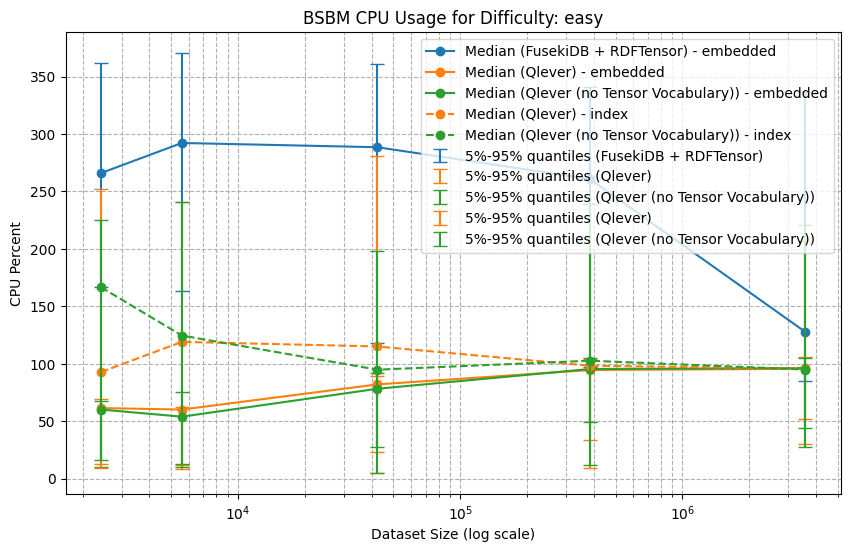

In [50]:
# plot the stats for the same runs, e.g. number of triples scanned, number of candidates, etc.


fig, axes = plt.subplots(len(difficulties), 1, figsize=(10, 6 * len(difficulties)))
for i, difficulty in enumerate(difficulties):
    ax = axes[i] if len(difficulties) > 1 else axes
    # set the subtitle to the difficulty

    plot_timings(ax, stats_df, engines, difficulty, relevant_measure="cpu_percent")
    ax.set_xscale("log")
    ax.set_xlabel("Dataset Size (log scale)")
    ax.set_ylabel("CPU Percent")
    ax.set_title(f"BSBM CPU Usage for Difficulty: {difficulty}")
    ax.legend()
    ax.grid(True, which="both", ls="--")
plt.savefig("./scratch/bsbm_cpu_usage.png")
plt.show()


/tmp/ipykernel_4154869/2830796753.py:28: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(


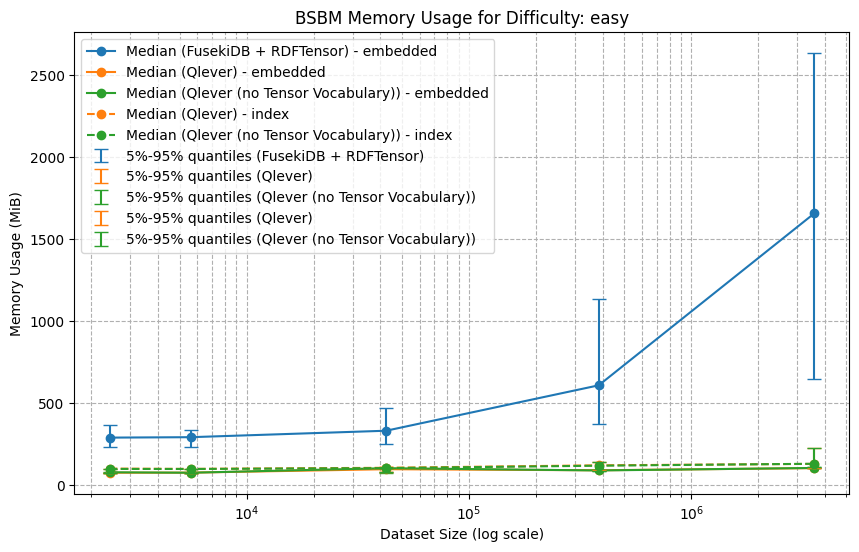

In [51]:
# plot the stats for the same runs, e.g. number of triples scanned, number of candidates, etc.


fig, axes = plt.subplots(len(difficulties), 1, figsize=(10, 6 * len(difficulties)))
for i, difficulty in enumerate(difficulties):
    ax = axes[i] if len(difficulties) > 1 else axes
    # set the subtitle to the difficulty

    plot_timings(ax, stats_df, engines, difficulty, relevant_measure="mem_usage_mb")
    ax.set_xscale("log")
    ax.set_xlabel("Dataset Size (log scale)")
    ax.set_ylabel("Memory Usage (MiB)")
    ax.set_title(f"BSBM Memory Usage for Difficulty: {difficulty}")
    ax.legend()
    ax.grid(True, which="both", ls="--")
plt.savefig("./scratch/bsbm_mem_usage.png")
plt.show()
